# fableScalar: a quintessence field and its equation of state

This notebook integrates **Model A** (the scalar field `fableScalar` rolling in a potential and
sourcing the expansion of a flat universe, the standard quintessence reference model) and
**Model A′** (the same field as a test field on the *Unite* CPL background) with the Rust solver
`fable_cosmo` (pure-Rust SUNDIALS 7.8.0 CVODE), for six potentials and several parameter values.
For every run it plots `w(a)`, fits the CPL line `w0 + wa (1 − a)` over the supernova range,
classifies the run as thawing or freezing in the Caldwell–Linder plane, re-integrates it with
scipy's DOP853 as a cross-check, and, for the reference case, compares three integrators (CVODE,
scipy, Mathematica `NDSolve`).  The last sections answer, from the numbers, which exponential
potential comes closest to Unite's `(w0, wa) = (−0.861, −0.60)` and whether `|wa| = 0.6` is
reachable by a field that never crosses `w = −1`.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that the solver is built on:
`rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11, `rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on
Apple-silicon macOS, `rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the solver with `cargo build --release` and smoke-tests it:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild the solver alone, run
`cargo build --release` inside `rust/fable_cosmo`.

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fableScalar` is one real number
  per point (a scalar field, written phi); `fable` is sixteen real numbers per point that rotate
  into each other under the symmetry group Spin(4,4) of the 8-dimensional pre-universe (a real
  16-component spinor field, written Psi).
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions.  The field equations follow from it by the
  Euler-Lagrange rule.  In curved space-time L carries the volume factor Sqrt[det g].
- **energy-momentum tensor** T_{mu nu} -- the response of the action to a change of the metric;
  its components measured by an observer are the energy density and the pressures.
- **energy density rho** -- energy per unit volume seen by the observer moving along the time
  coordinate (here rho = T_{44}, the time being x4 on the pre-universe and t in the reference
  models).
- **pressure P** -- the spatial diagonal components of T (P_i = T^i_i, i = 1, 2, 3); the fields
  are homogeneous, so P_1 = P_2 = P_3 = P.
- **equation of state w = P / rho** -- the single number that fixes how the energy density of a
  component dilutes as the universe expands: rho is proportional to a^{-3(1+w)}.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today).
- **redshift z = 1/a - 1** -- what an astronomer measures; z = 0 today, z = 1 when a = 1/2.
- **N = ln a** -- the number of e-folds of expansion; the independent variable of the solver.
  N = -7 is a = 9.1e-4 (z = 1096, just after radiation-matter equality, which with the
  parameters used here is at a_eq = Omega_r0/Omega_m0 = 2.8e-4), N = 0 is today.
- **Hubble rate H = (da/dt)/a** -- the expansion rate; in this notebook it is measured in units
  of its value today, so H(a = 1) = 1.
- **Omega_i** -- the fraction of the critical density 3 H^2 carried by component i (matter m,
  radiation r, or the field).  Today Omega_m = 0.3, Omega_r = 8.4e-5 and the field carries the
  rest, 0.699916.
- **CPL (w0, wa)** -- the Chevallier-Polarski-Linder straight line w(a) = w0 + wa (1 - a): w0 is
  w today, w0 + wa is the value the line extrapolates to at a = 0.  The Supernovae *Unite*
  fits are (w0, wa) = (-0.861, -0.60) and, forcing a constant w, w = -0.764.
- **thawing / freezing** -- a field whose w rises with time (dw/dN > 0) is *thawing* (it starts
  frozen at w = -1 and wakes up); one whose w falls towards -1 is *freezing*.  We read the
  class off the sign of dw/dN over the fit range, not off the potential's name.
- **phantom** -- w < -1.  A canonical scalar field cannot get there (its rho + P = 2 KE >= 0);
  crossing w = -1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, rho proportional to a^{-3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = -1 exactly.
- **kination** -- a scalar field whose energy is all kinetic: w = +1, rho proportional to a^{-6}.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y' = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep, for smooth non-stiff oscillations) are its two families of methods.  The solver
  here uses the pure-Rust port of SUNDIALS 7.8.0 of the rustSolveIt repositories.
- **tolerance** -- CVODE keeps the local error of every step below rtol * |y| + atol; the runs
  use rtol = 1e-10, atol = 1e-12.  The cross-checks re-integrate with scipy at rtol = 1e-11.

## 3. The field, its Lagrangian and its energy-momentum tensor

**On the 8-dimensional pre-universe (what Part VI of the Mathematica notebook proves).**  The
pre-universe has coordinates `X = {x0, …, x7}`, flat metric `eta = diag(+,+,+,+,−,−,−,−)`, the
canonical frame `e = diag(Tan[6Hx0], q, q, q, 1, p, p, p)` with `q = e^{−a4[Hx4]}/Sin[6Hx0]^{1/6}`,
`p = e^{+a4[Hx4]}/Sin[6Hx0]^{1/6}`, hence `g = diag(Tan², q², q², q², −1, −p², −p², −p²)` and
`Sqrt[det g] = Sec[6Hx0]`.  `H` is the notebook's constant; the undetermined function `a4` is
never given a value anywhere in this work.  The observer's time is `t ≡ x4` (`g44 = −1`) and
the observed 3-space is `(x1, x2, x3)`, whose frame entry at fixed `x0` is the scale factor:
`a(t) ∝ e^{−a4[Ht]}` (a kinematic identification only; the sheet expands where `a4′ < 0`).

`fableScalar ≡ φ(x)` is a real scalar field on the 8-manifold, minimally coupled, with a
self-interaction potential `V(φ)`:

    L_φ = Sqrt[det g] · L̂_φ,        L̂_φ = −½ g^{μν} ∂_μφ ∂_νφ − V(φ)

(the sign makes the x4-kinetic term positive: `−½ g^{44} φ̇² = +½ φ̇²`).  Its energy–momentum
tensor, `T_{μν} = −(2/Sqrt[g]) δS/δg^{μν}`, is

    T_{μν} = ∂_μφ ∂_νφ + g_{μν} L̂_φ .

Part VI asserts that it is symmetric, that `∇^μ T_{μν} = (□φ − V′(φ)) ∂_νφ` holds *off shell* for
a generic `φ(x0, …, x7)` (so conservation on shell is exact), and that the trace is
`T^μ_μ = −3(∂φ)² − 8V`.  For a field depending on `x0`, `x4` and the second-sheet coordinates,
the observer `u = ∂_4` measures

    KE = ½ φ̇²                       (x4 kinetic energy)
    PE = V(φ)                       (potential energy)
    G0 = ½ Cot[6Hx0]² (∂_0 φ)²      (gradient energy along the hidden coordinate x0)
    G5 = ½ (1/p²) Σ_{i=5,6,7} (∂_i φ)²   (gradient energy along the second, timelike sheet)

    ρ_φ = KE + PE + G0 − G5,       P_φ = KE − PE − G0 + G5,       wScalar ≡ w_φ = P_φ / ρ_φ .

Two consequences proved there and used here: **the null energy condition holds identically**,
`ρ_φ + P_φ = 2 KE ≥ 0`, so `w_φ ≥ −1` wherever `ρ_φ > 0` (guaranteed for `V ≥ 0` and any field
independent of `x5, x6, x7`): fableScalar cannot cross the phantom divide; and **there is no
Hubble friction in x4** on the pre-universe, because `Sqrt[g] g^{44} = −Sec[6Hx0]` does not
depend on `x4` (the observed sheet's expansion is compensated by the second sheet's contraction).

**The 4-dimensional reference model (what this notebook integrates).**  Integrating the
8-dimensional action over the hidden coordinates gives a hidden 4-volume density
`𝒱_hid ∝ a^{−3}`, so the reduced density `ρ_4 ∝ a^{−3} ρ_8` is not separately conserved and the
framework, having no gravitational sector (no Einstein equations, `a4` free), does not say which
density gravitates.  The **standard quintessence model** — `φ̈ + 3Hφ̇ + V′(φ) = 0` with the
Friedmann equation on a separate FLRW frame `diag(1, a, a, a, 1, 1, 1, 1)` — is what one obtains
when the hidden volume is held fixed and the field sources the expansion.  It is the reference
model of the CPL fits, and it is what Model A integrates; it is never a substitution into the
canonical frame and never gives `a4` a value.  With `G0 = G5 = 0` the energies reduce to the
usual `ρ = ½φ̇² + V`, `P = ½φ̇² − V`, `w = P/ρ`.

## 4. The equations of motion

Units: `M_pl² = 1/(8πG) = 1`, `H0 = 1` (time in `1/H0`), `a0 = 1`, so the critical density today
is `ρ_crit,0 = 3 H0² M_pl² = 3` and `ρ_m = 3 Ω_m0 e^{−3N}`, `ρ_r = 3 Ω_r0 e^{−4N}` with
`Ω_m0 = 0.3`, `Ω_r0 = 8.4e−5`.  The independent variable is `N = ln a`.  The scalar field obeys
the Klein–Gordon equation with Hubble friction, `φ̈ + 3Hφ̇ + V′(φ) = 0`, and the Friedmann
equation closes the system:

    H² = (ρ_m + ρ_r + ρ_φ)/3 = Ω_m0 e^{−3N} + Ω_r0 e^{−4N} + (½φ̇² + V(φ))/3,    so H(N = 0) = 1 exactly.

**Model A′** uses instead the fixed CPL background of the *Unite* fit,
`H² = Ω_m0 e^{−3N} + Ω_r0 e^{−4N} + Ω_DE0 f(a)` with
`f(a) = ρ_DE(a)/ρ_DE0 = a^{−3(1+w0+wa)} e^{−3wa(1−a)}` (the closed form of
`exp(3∫_a^1 (1 + w(a′)) da′/a′)`, unit-tested against the integral; `f(1) = 1`); the field
does not source `H` there.

### 4.1 The first-order system actually handed to SUNDIALS

The state vector is `y = (φ, φ̇, t)` and the independent variable is `N`; `models.rs` integrates

    dφ/dN  = φ̇ / H
    dφ̇/dN = −3 φ̇ − V′(φ) / H
    dt/dN  = 1 / H                     (cosmic time, carried as a state variable)

with `H = H(N, φ, φ̇)` from the Friedmann equation above (Model A, `rhs_scalar_flrw`) or from the
CPL background (Model A′, `rhs_scalar_cpl`).  CVODE runs BDF with Newton iteration and a dense
finite-difference Jacobian, `rtol = 1e−10`, `atol = 1e−12`, `CVodeSetStopTime`, and returns the
state at 701 equally spaced values of `N` (`CV_NORMAL`).

*Initial conditions.*  Every FLRW run starts at `N0 = −7` (`a ≈ 9.1e−4`, `z ≈ 1100`; with
`Ω_r0 = 8.4e−5` radiation–matter equality is at `a_eq = Ω_r0/Ω_m0 = 2.8e−4`, so the start is
just after it, with radiation still 24 % of the density) from rest, `φ̇(N0) = 0` (the frozen
start), at a value `φ_i` that the solver prints and that `--param phi_i=… --param phidot_i=…`
overrides: `exp`: 0, `invpower`: 0.2, `pngb`: `0.5 f`, `hilltop`: `0.1 μ`, `const`: 0.  The age
of the universe at `N0` is added analytically, `t_age(N0) = 1/(2 H(N0))` (the exact age of a
radiation-dominated universe with that Hubble rate; since matter already dominates at `N0` the
true age lies between this and `2/(3H(N0))`, an uncertainty of a third of `2.2e−5/H0`,
negligible against `t ≈ 1/H0` today, but stated and printed).

*Normalisation.*  Rescaling `V → kV` is not a symmetry of the equations, so the overall scale of
`V` is found by shooting: bisection on `log10 k` in the bracket `[10^{−6}, 10^{6}]`, 80
iterations or `Δlog10 k < 1e−13`, until `Ω_φ(a = 1) = 1 − Ω_m0 − Ω_r0 = 0.699916` (Model A) or
`ρ_φ(a = 1)/3 = Ω_DE0` (Model A′).  The solver exits with code 1 and a one-line reason if the
target is not bracketed (a field that has joined the scaling solution of the exponential
potential with `λ² > 3` can never carry 70 % of the density: we meet this below) or if
`ρ_φ ≤ 0` anywhere on the run.  `--no-normalize` keeps the parameters as given.

*Potentials* (`potentials.rs`): `exp` `V0 e^{−λφ}`, `invpower` `V0 φ^{−α}`, `pngb`
`V0 (1 + cos(φ/f))`, `quadratic` `½m²φ²`, `hilltop` `V0 (1 − φ²/μ²)` (used where `V > 0`),
`const` `V0` (the control, `w = −1`).

*Outputs per point*: `a, z, N, t, phi, phidot, H, KE, PE, rho_phi, P_phi, w_phi, Omega_phi,
Omega_m, Omega_r, q_dec` with `q_dec = −1 − (dH/dN)/H`; Model A′ replaces the last four by
`w_cpl, Omega_phi_test, Omega_DE_cpl`.

## 5. Running the solver

The binary is `rust/fable_cosmo/target/release/fable_cosmo` (`.exe` on Windows), built by the
setup.  Its command line is

    fable_cosmo <model> [--potential NAME] [--param KEY=VALUE ...] [--n0 X0] [--n1 X1] [--points K]
                [--out FILE.csv] [--no-normalize] [--rtol R] [--atol A] [--method bdf|adams]

with `model` one of `scalar-flrw` (Model A) and `scalar-cpl` (Model A′) here; defaults
`--n0 -7 --n1 0 --points 701`.  It writes a CSV whose header line names every column (15
significant digits) and prints to stderr the initial conditions, a `# stats:` line with the
CVODE step and function-evaluation counts, the potential *after* normalisation, and its version.
Exit code 0 is success, 1 a solver or physics error with a one-line reason, 2 a usage error.

The next cell locates the binary relative to this notebook, checks that it runs, and defines the
helpers used throughout: `run_solver` (runs one case, prints the solver's stderr and returns the
CSV as a numpy record array), the Python copies of the potentials, the CPL fit, the
thawing/freezing classifier, the plotting functions, and the scipy re-integration.  Nothing
here is random; every number is reproducible.

In [1]:
import os, sys, re, csv, io, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_cosmo' / 'target' / 'release' / ('fable_cosmo.exe' if os.name == 'nt' else 'fable_cosmo')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
print(subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip())
print('results directory:', RESULTS)

OM, OR = 0.3, 8.4e-5                       # Omega_m0, Omega_r0: the solver's defaults
OMEGA_FIELD_TODAY = 1.0 - OM - OR          # 0.699916, what the field must carry today
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
RUNS = {}                                  # every solver run of this notebook, by result-file name


def parse_stderr(text):
    """The potential (name and parameters after normalisation) that the solver printed on stderr."""
    m = re.search(r'# potential=(\S+) \w+ \{ ([^}]*)\}', text)
    if not m:
        return None, {}
    params = {k: float(v) for k, v in re.findall(r'(\w+): ([-+0-9.eE]+)', m.group(2))}
    return m.group(1), params


def run_solver(name, model, *args, label=None, expect_failure=False, keep=True, quiet=False):
    """Run fable_cosmo; write results/<name>.csv (unless keep=False); print its stderr; return the table.

    With expect_failure=True the non-zero exit is caught and the solver's one-line reason is printed;
    the CompletedProcess is returned instead of a table.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), model, *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_cosmo', model, *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown.replace(str(RESULTS) + os.sep, 'results/').replace(str(RESULTS), 'results'))
    if expect_failure:
        r = subprocess.run(cmd, capture_output=True, text=True)
        reason = r.stderr.strip().splitlines()[-1] if r.stderr.strip() else '(no message)'
        print(f'  exit code {r.returncode}: {reason}')
        return r
    r = subprocess.run(cmd, check=True, capture_output=True, text=True)
    for line in r.stderr.strip().splitlines():
        if not quiet or line.startswith('# stats'):
            print(' ', line)
    table = np.genfromtxt(out, delimiter=',', names=True) if keep else np.genfromtxt(io.StringIO(r.stdout), delimiter=',', names=True)
    pot, params = parse_stderr(r.stderr)
    RUNS[name] = dict(label=label or name, model=model, args=args, table=table, pot=pot, params=params, stderr=r.stderr)
    return table


def scalar_potential(name, p):
    """V(phi) and V'(phi) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'exp':
        return (lambda x: p['v0'] * np.exp(-p['lambda'] * x), lambda x: -p['lambda'] * p['v0'] * np.exp(-p['lambda'] * x))
    if name == 'invpower':
        return (lambda x: p['v0'] * x ** (-p['alpha']), lambda x: -p['alpha'] * p['v0'] * x ** (-p['alpha'] - 1.0))
    if name == 'pngb':
        return (lambda x: p['v0'] * (1.0 + np.cos(x / p['f'])), lambda x: -p['v0'] / p['f'] * np.sin(x / p['f']))
    if name == 'quadratic':
        return (lambda x: 0.5 * p['m'] ** 2 * x * x, lambda x: p['m'] ** 2 * x)
    if name == 'hilltop':
        return (lambda x: p['v0'] * (1.0 - x * x / p['mu'] ** 2), lambda x: -2.0 * p['v0'] * x / p['mu'] ** 2)
    if name == 'const':
        return (lambda x: p['v0'] + 0.0 * x, lambda x: 0.0 * x)
    if name == 'quartic':
        return (lambda x: 0.25 * p['lambda'] * x ** 4, lambda x: p['lambda'] * x ** 3)
    raise ValueError(name)


def spinor_potential(name, p):
    """V(s) and V'(s) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'mass':
        return (lambda s: p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'lambda-mass':
        return (lambda s: p['v0'] + p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'power':
        return (lambda s: p['m'] * s + p['lambda'] * s ** p['n'], lambda s: p['m'] + p['n'] * p['lambda'] * s ** (p['n'] - 1.0))
    if name == 'hilltop':
        return (lambda s: p['v0'] - p['mu'] * (s - p['sstar']) ** 2, lambda s: -2.0 * p['mu'] * (s - p['sstar']))
    if name == 'lorentz':
        return (lambda s: p['v0'] + p['m'] * s / (1.0 + (s / p['s1']) ** 2),
                lambda s: p['m'] * (1.0 - (s / p['s1']) ** 2) / (1.0 + (s / p['s1']) ** 2) ** 2)
    if name == 'expdamp':
        return (lambda s: p['v0'] + p['m'] * s * np.exp(-s / p['s1']), lambda s: p['m'] * (1.0 - s / p['s1']) * np.exp(-s / p['s1']))
    raise ValueError(name)


def cpl_h2(a, w0=UNITE_W0, wa=UNITE_WA):
    """H^2 of the CPL background (H0 = 1): the closed form of rho_DE(a)/rho_DE(1) of models.rs."""
    return OM * a ** -3 + OR * a ** -4 + OMEGA_FIELD_TODAY * a ** (-3.0 * (1.0 + w0 + wa)) * np.exp(-3.0 * wa * (1.0 - a))


def cpl_fit(a, w, amin=0.3, amax=1.0):
    """Unweighted least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (numpy.polyfit on 1 - a)."""
    m = (a >= amin) & (a <= amax)
    wa, w0 = np.polyfit(1.0 - a[m], w[m], 1)
    return float(w0), float(wa)


def w_at(a, w, a0):
    """w interpolated at a0 (NaN if a0 lies outside the run)."""
    if a0 < a[0] or a0 > a[-1]:
        return float('nan')
    return float(np.interp(a0, a, w))


def thaw_class(N, w, a, tol=1e-6):
    """'thawing' if dw/dN > 0 over the whole fit range 0.3 <= a <= 1, 'freezing' if < 0, 'constant' if |dw/dN| < tol, else 'mixed'."""
    m = (a >= 0.3) & (a <= 1.0)
    d = np.gradient(w, N)[m]
    if np.max(np.abs(d)) < tol:
        return 'constant'
    if np.min(d) > -tol:
        return 'thawing'
    if np.max(d) < tol:
        return 'freezing'
    return 'mixed'


def crossings(N, w):
    """Every scale factor at which w + 1 changes sign, by a local degree-6 polynomial through the 8 grid
    points around the sign change and a root bracket (brentq); [] if w never crosses -1."""
    f = w + 1.0
    out = []
    for i in np.where(np.sign(f[:-1]) * np.sign(f[1:]) < 0)[0]:
        lo, hi = max(0, i - 3), min(len(N), i + 5)
        c = np.polyfit(N[lo:hi] - N[i], f[lo:hi], min(6, hi - lo - 1))
        out.append(float(np.exp(N[i] + brentq(lambda x: np.polyval(c, x), 0.0, N[i + 1] - N[i]))))
    return out


FIT_COLUMNS = ['run', 'model', 'w0_fit', 'wa_fit', 'w0_plus_wa', 'w_a03', 'w_a1', 'w_min', 'class', 'omega_today', 'dist_to_unite']


def fit_row(name, wcol):
    """One row of the CPL table for a run in RUNS."""
    r = RUNS[name]
    d = r['table']
    a, w, N = d['a'], d[wcol], d['N']
    w0, wa = cpl_fit(a, w)
    om_col = next(c for c in ('Omega_phi', 'Omega_Psi', 'Omega_phi_test') if c in d.dtype.names)
    return {'run': r['label'], 'model': r['model'], 'w0_fit': w0, 'wa_fit': wa, 'w0_plus_wa': w0 + wa,
            'w_a03': w_at(a, w, 0.3), 'w_a1': float(w[-1]), 'w_min': float(w.min()), 'class': thaw_class(N, w, a),
            'omega_today': float(d[om_col][-1]), 'dist_to_unite': float(np.hypot(w0 - UNITE_W0, wa - UNITE_WA))}


UNITE_ROWS = [
    {'run': 'Unite CPL (w0, wa)', 'model': 'reference', 'w0_fit': UNITE_W0, 'wa_fit': UNITE_WA, 'w0_plus_wa': UNITE_W0 + UNITE_WA,
     'w_a03': UNITE_W0 + UNITE_WA * 0.7, 'w_a1': UNITE_W0, 'w_min': float('nan'), 'class': 'CPL line', 'omega_today': OMEGA_FIELD_TODAY, 'dist_to_unite': 0.0},
    {'run': 'Unite constant w', 'model': 'reference', 'w0_fit': UNITE_WCONST, 'wa_fit': 0.0, 'w0_plus_wa': UNITE_WCONST,
     'w_a03': UNITE_WCONST, 'w_a1': UNITE_WCONST, 'w_min': UNITE_WCONST, 'class': 'constant', 'omega_today': OMEGA_FIELD_TODAY,
     'dist_to_unite': float(np.hypot(UNITE_WCONST - UNITE_W0, 0.0 - UNITE_WA))},
]


def fit_table(rows, path):
    """Print the CPL table next to Unite's numbers and write it (with the two Unite reference rows) to `path`."""
    hdr = f"{'run':44s} {'w0_fit':>8s} {'wa_fit':>8s} {'w0+wa':>8s} {'w(0.3)':>8s} {'w(1)':>8s} {'min w':>8s}  {'class':9s} {'Omega(1)':>8s} {'dist':>6s}"
    print(hdr)
    print('-' * len(hdr))
    for r in rows + UNITE_ROWS:
        print(f"{r['run']:44s} {r['w0_fit']:8.4f} {r['wa_fit']:8.4f} {r['w0_plus_wa']:8.4f} {r['w_a03']:8.4f} {r['w_a1']:8.4f} {r['w_min']:8.4f}  {r['class']:9s} {r['omega_today']:8.4f} {r['dist_to_unite']:6.3f}")
    with open(path, 'w', newline='') as f:
        wr = csv.DictWriter(f, fieldnames=FIT_COLUMNS)
        wr.writeheader()
        for r in rows + UNITE_ROWS:
            wr.writerow({k: (f'{v:.10g}' if isinstance(v, float) else v) for k, v in r.items()})
    print('written:', path.relative_to(ROOT).as_posix())


def plot_w_of_a(entries, fname, title, fits=True, ylim=None):
    """w(a) over the full run (left, log a) and zoomed to 0.3 <= a <= 1 (right) with each run's CPL fit
    (dashed) and Unite's CPL line (dotted).  entries = [(label, table, w-column), ...]."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
    au = np.linspace(0.3, 1.0, 200)
    for label, d, wcol in entries:
        a, w = d['a'], d[wcol]
        line, = ax1.plot(a, w, lw=1.2, label=label)
        ax2.plot(a, w, lw=1.4, color=line.get_color(), label=label)
        if fits and a[0] <= 0.31:
            w0, wa = cpl_fit(a, w)
            ax2.plot(au, w0 + wa * (1.0 - au), '--', lw=0.9, color=line.get_color())
    afull = np.geomspace(min(d['a'][0] for _, d, _ in entries), 1.0, 300)
    ax1.plot(afull, UNITE_W0 + UNITE_WA * (1.0 - afull), 'k:', lw=1.2, label='Unite CPL line, extrapolated')
    ax2.plot(au, UNITE_W0 + UNITE_WA * (1.0 - au), 'k:', lw=2.0, label='Unite CPL (-0.861, -0.60)')
    ax2.axhline(UNITE_WCONST, color='0.4', lw=0.8, ls='-.', label='Unite constant w = -0.764')
    for ax in (ax1, ax2):
        ax.axhline(-1.0, color='k', lw=0.5)
        ax.set_xlabel('a')
        ax.set_ylabel('w')
        if ylim:
            ax.set_ylim(*ylim)
    ax1.set_xscale('log')
    ax1.set_title(f'{title}: the whole run')
    ax2.set_xlim(0.3, 1.0)
    ax2.set_title('0.3 <= a <= 1 (supernova range) with the CPL fits, dashed')
    ax1.legend(fontsize=7, loc='best')
    ax2.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def plot_caldwell_linder(entries, fname, title):
    """The Caldwell-Linder plane w' = dw/dN versus w over a >= 0.3, with the thawing and freezing wedges
    as guides; the class printed in the legend is the sign of dw/dN over the fit range (the rule used here)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    wg = np.linspace(-1.0, -0.2, 60)
    ax.fill_between(wg, 1.0 + wg, 3.0 * (1.0 + wg), color='tab:red', alpha=0.08, label="thawing wedge: 1+w < w' < 3(1+w)")
    ax.fill_between(wg, 3.0 * wg * (1.0 + wg), 0.2 * wg * (1.0 + wg), color='tab:blue', alpha=0.08, label="freezing wedge: 3w(1+w) < w' < 0.2w(1+w)")
    for label, d, wcol in entries:
        a, w, N = d['a'], d[wcol], d['N']
        m = a >= 0.3
        wp = np.gradient(w, N)
        line, = ax.plot(w[m], wp[m], lw=1.2, label=f'{label}: {thaw_class(N, w, a)}')
        ax.plot(w[-1], wp[-1], 'o', ms=4, color=line.get_color())
    ax.axhline(0.0, color='k', lw=0.5)
    ax.set_xlabel('w')
    ax.set_ylabel("w' = dw/dN")
    ax.set_title(title + ' (dot = today)')
    ax.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def scipy_scalar(name, cpl=False):
    """Re-integrate a Model A (or, with cpl=True, Model A') run with scipy DOP853 at rtol 1e-11 from the
    same initial state and the same normalised potential; return max |w_rust - w_scipy| and max |t_rust - t_scipy|."""
    r = RUNS[name]
    d = r['table']
    V, dV = scalar_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, phi, phid):
        if cpl:
            return np.sqrt(cpl_h2(np.exp(n)))
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + (0.5 * phid * phid + V(phi)) / 3.0)

    def rhs(n, y):
        phi, phid, t = y
        h = H(n, phi, phid)
        return [phid / h, -3.0 * phid - dV(phi) / h, 1.0 / h]

    sol = solve_ivp(rhs, (N[0], N[-1]), [d['phi'][0], d['phidot'][0], 0.0], method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    phi, phid = sol.y[0], sol.y[1]
    w = (0.5 * phid ** 2 - V(phi)) / (0.5 * phid ** 2 + V(phi))
    t = sol.y[2] + 0.5 / H(N[0], d['phi'][0], d['phidot'][0])      # the same analytic age offset t_age(N0) = 1/(2 H(N0))
    return float(np.abs(w - d['w_phi']).max()), float(np.abs(t - d['t']).max()), w


def scipy_spinor(name):
    """Re-integrate a Model B run with scipy DOP853 at rtol 1e-11: ds/dN = -3 s, dt/dN = 1/H; compare w and t."""
    r = RUNS[name]
    d = r['table']
    V, dV = spinor_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, s):
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + V(s) / 3.0)

    sol = solve_ivp(lambda n, y: [-3.0 * y[0], 1.0 / H(n, y[0])], (N[0], N[-1]), [d['s'][0], 0.0],
                    method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    s = sol.y[0]
    w = s * dV(s) / V(s) - 1.0
    t = sol.y[1] + 0.5 / H(N[0], d['s'][0])
    return float(np.abs(w - d['w_Psi']).max()), float(np.abs(t - d['t']).max()), w

fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
results directory: C:\Users\nsh\Documents\8-dim\Pre-Universe_14SEP26-77\fable-cosmology\results


### 5.1 The exponential potential, `V = V0 e^{−λφ}`, for λ = 0.5, 1, 1.5, 2 and 3

The reference case is `λ = 1` (its Mathematica `NDSolve` twin is compared in 5.8).  Each run
starts frozen at `φ_i = 0`; the solver normalises `V0` so that the field carries 69.99 % of the
density today.  Watch the `# potential=` line: it is the `V0` after normalisation, and it is the
value the scipy cross-check and the Mathematica reference use.  Nothing is fitted yet: the
table of 5.6 does that for all runs at once.

In [2]:
for lam in [0.5, 1, 1.5, 2]:
    d = run_solver(f'nb01_exp_lambda{lam}', 'scalar-flrw', '--potential', 'exp', '--param', f'lambda={lam}', label=f'exp lambda={lam}')
    print(f'  -> w(a=1) = {d["w_phi"][-1]:+.5f}   Omega_phi(a=1) = {d["Omega_phi"][-1]:.6f}   min w = {d["w_phi"].min():+.6f}\n')

$ fable_cosmo scalar-flrw --potential exp --param lambda=0.5 --out results/nb01_exp_lambda0.5.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=384 rhs_evals=424 nonlin_iters=421 err_test_fails=5
  # potential=exp Exp { v0: 2.222203568164536, lambda: 0.5 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.96162   Omega_phi(a=1) = 0.699916   min w = -1.000000

$ fable_cosmo scalar-flrw --potential exp --param lambda=1 --out results/nb01_exp_lambda1.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=385 rhs_evals=434 nonlin_iters=431 err_test_fails=5
  # potential=exp Exp { v0: 2.6871520526047146, lambda: 1.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.84336   Omega_phi(a=1) = 0.699916   min w = -1.000000

$ fable_cosmo scalar-flrw --potential exp --param lambda=1.5 --out results/nb01_exp_lambda1.5.csv

`λ = 3` is different: for `λ² > 3` the late-time attractor of the exponential potential is the
*scaling* solution, on which the field tracks the dominant component (`w_φ = w_m = 0` in the
matter era) with a fixed share `Ω_φ = 3/λ²`; whatever `V0` is, `Ω_φ(a = 1)` never reaches
0.70, so the normalisation cannot bracket its target and the solver refuses with a one-line
reason (we catch the exit code and print it).  To show what the field does instead, the same
potential is then run with the scale fixed by hand (`--no-normalize --param v0=1e6`, deep on
the attractor): it is not a dark-energy model, and its row in the fit table is marked.

In [3]:
r = run_solver('nb01_exp_lambda3', 'scalar-flrw', '--potential', 'exp', '--param', 'lambda=3', expect_failure=True)
assert r.returncode == 1, 'the normalisation of lambda = 3 was expected to fail'
print()
d = run_solver('nb01_exp_lambda3_scaling', 'scalar-flrw', '--potential', 'exp', '--param', 'lambda=3', '--no-normalize', '--param', 'v0=1e6',
               label='exp lambda=3 (scaling; --no-normalize v0=1e6)')
print(f'  -> Omega_phi(a=1) = {d["Omega_phi"][-1]:.4f} (the scaling value 3/lambda^2 = {3/9:.4f}),  w(a=1) = {d["w_phi"][-1]:+.4f},  q_dec(a=1) = {d["q_dec"][-1]:+.4f}')

$ fable_cosmo scalar-flrw --potential exp --param lambda=3 --out results/nb01_exp_lambda3.csv
  exit code 1: fable_cosmo: normalisation cannot bracket Omega_phi = 0.699916: Omega(10^-6 V) = 0.0000011107972084367645, Omega(10^6 V) = 0.3375115141492524; choose the scale by hand and pass --no-normalize

$ fable_cosmo scalar-flrw --potential exp --param lambda=3 --no-normalize --param v0=1e6 --out results/nb01_exp_lambda3_scaling.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198012e-5
  # stats: model=scalar-flrw steps=662 rhs_evals=697 nonlin_iters=696 err_test_fails=4
  # potential=exp Exp { v0: 1000000.0, lambda: 3.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> Omega_phi(a=1) = 0.3375 (the scaling value 3/lambda^2 = 0.3333),  w(a=1) = -0.0039,  q_dec(a=1) = +0.4981


### 5.2 The inverse power potential, `V = V0 φ^{−α}`, α = 1: is the tracker joined?

The Ratra–Peebles potential has a *tracker* solution (`w_φ = −2/(α + 2) = −2/3` in the matter
era for `α = 1`) that attracts a wide range of initial conditions; a field on the tracker is
*freezing* (its `w` falls towards −1 as it comes to dominate).  With the solver's frozen start
(`φ_i = 0.2`, `φ̇_i = 0` at `N0 = −7`) the field may or may not have reached the tracker by
today.  We run the default start and then start much earlier (`--n0 -25`, `a = 1.4e−11`) to see
whether the extra e-folds let the field join the tracker; both are reported.

In [4]:
d1 = run_solver('nb01_invpower_alpha1', 'scalar-flrw', '--potential', 'invpower', '--param', 'alpha=1', label='invpower alpha=1 (N0=-7)')
print()
d2 = run_solver('nb01_invpower_alpha1_n0-25', 'scalar-flrw', '--potential', 'invpower', '--param', 'alpha=1', '--n0', '-25', '--points', '2501',
                label='invpower alpha=1 (N0=-25)')
print()
for lab, d in [('N0 = -7 ', d1), ('N0 = -25', d2)]:
    w_of = lambda n: float(np.interp(n, d['N'], d['w_phi']))
    print(f'{lab}: w(N=-6) = {w_of(-6):+.5f}  w(N=-4) = {w_of(-4):+.5f}  w(N=-2) = {w_of(-2):+.5f}  w(a=0.3) = {w_at(d["a"], d["w_phi"], 0.3):+.5f}  w(a=1) = {d["w_phi"][-1]:+.5f}  phi(a=1) = {d["phi"][-1]:.5f}')
i7 = int(np.argmin(np.abs(d2['N'] + 7.0)))
print(f'the N0=-25 run at N = {d2["N"][i7]:.2f}: w = {d2["w_phi"][i7]:+.6f}, phi = {d2["phi"][i7]:.6f}, phidot = {d2["phidot"][i7]:.3e}   (tracker value in the matter era: w = -2/(alpha+2) = {-2/3:+.4f})')
w2_on_1 = np.interp(d1['N'], d2['N'], d2['w_phi'])
print(f'max |w(N0=-25) - w(N0=-7)| on the common range N >= -7: {np.abs(w2_on_1 - d1["w_phi"]).max():.2e}')

$ fable_cosmo scalar-flrw --potential invpower --param alpha=1 --out results/nb01_invpower_alpha1.csv
  # initial conditions: N0=-7 phi_i=0.2 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=430 rhs_evals=493 nonlin_iters=490 err_test_fails=9
  # potential=invpower InvPower { v0: 1.9809949936812625, alpha: 1.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo scalar-flrw --potential invpower --param alpha=1 --n0 -25 --points 2501 --out results/nb01_invpower_alpha1_n0-25.csv


  # initial conditions: N0=-25 phi_i=0.2 phidot_i=0 t_age(N0)=1.052219e-20
  # stats: model=scalar-flrw steps=517 rhs_evals=619 nonlin_iters=616 err_test_fails=19
  # potential=invpower InvPower { v0: 1.9809949831179463, alpha: 1.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

N0 = -7 : w(N=-6) = -1.00000  w(N=-4) = -0.99975  w(N=-2) = -0.92110  w(a=0.3) = -0.72982  w(a=1) = -0.75324  phi(a=1) = 1.07623
N0 = -25: w(N=-6) = -1.00000  w(N=-4) = -0.99975  w(N=-2) = -0.92110  w(a=0.3) = -0.72982  w(a=1) = -0.75324  phi(a=1) = 1.07623
the N0=-25 run at N = -7.00: w = -1.000000, phi = 0.200000, phidot = 4.695e-04   (tracker value in the matter era: w = -2/(alpha+2) = -0.6667)
max |w(N0=-25) - w(N0=-7)| on the common range N >= -7: 3.01e-08


The two starts give the same history to a few parts in 10⁵: the field is still frozen at
`w = −1` when `N = −7` arrives, whatever happened before (Hubble friction in the radiation era
is enormous, `3H ≫ V″^{1/2}`), so starting earlier adds nothing.  The field thaws late, its `w`
rises from −1, overshoots and turns down slightly before today: with a frozen start the inverse
power potential does **not** join its tracker by `a = 1`, and its class is read off `dw/dN`
below, not off the potential's reputation.

### 5.3 The pseudo-Nambu–Goldstone potential, the hilltop, and the constant (the control)

`pngb`: `V = V0 (1 + cos(φ/f))` with `f = 1` (start `φ_i = 0.5`), and `f = 0.5` started at
`φ_i = 0.3` (steeper, so the field thaws more).  `hilltop`: `V = V0 (1 − φ²/μ²)` with `μ = 3`
(start `φ_i = 0.3`, well inside `V > 0`).  `const`: `V = V0`, a cosmological constant; it must
give `w = −1` at every point, and the assertion below makes the notebook fail if it does not.

In [5]:
run_solver('nb01_pngb_f1', 'scalar-flrw', '--potential', 'pngb', '--param', 'f=1', label='pngb f=1')
print()
run_solver('nb01_pngb_f0.5', 'scalar-flrw', '--potential', 'pngb', '--param', 'f=0.5', '--param', 'phi_i=0.3', label='pngb f=0.5 phi_i=0.3')
print()
run_solver('nb01_hilltop_mu3', 'scalar-flrw', '--potential', 'hilltop', '--param', 'mu=3', label='hilltop mu=3')
print()
dc = run_solver('nb01_const', 'scalar-flrw', '--potential', 'const', label='const (control)')
dev = np.abs(dc['w_phi'] + 1.0).max()
print(f'\ncontrol: max |w + 1| over the run = {dev:.1e}')
assert dev < 1e-9, 'the constant potential must give w = -1 everywhere'

$ fable_cosmo scalar-flrw --potential pngb --param f=1 --out results/nb01_pngb_f1.csv
  # initial conditions: N0=-7 phi_i=0.5 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=312 rhs_evals=357 nonlin_iters=354 err_test_fails=5
  # potential=pngb Pngb { v0: 1.1365040386787846, f: 1.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo scalar-flrw --potential pngb --param f=0.5 --param phi_i=0.3 --out results/nb01_pngb_f0.5.csv


  # initial conditions: N0=-7 phi_i=0.3 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=313 rhs_evals=356 nonlin_iters=353 err_test_fails=3
  # potential=pngb Pngb { v0: 1.3334672012023139, f: 0.5 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo scalar-flrw --potential hilltop --param mu=3 --out results/nb01_hilltop_mu3.csv


  # initial conditions: N0=-7 phi_i=0.30000000000000004 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=305 rhs_evals=352 nonlin_iters=349 err_test_fails=4
  # potential=hilltop Hilltop { v0: 2.123182060650741, mu: 3.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo scalar-flrw --potential const --out results/nb01_const.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-flrw steps=306 rhs_evals=370 nonlin_iters=367 err_test_fails=13
  # potential=const Const { v0: 2.0997480000000657 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

control: max |w + 1| over the run = 0.0e+00


### 5.4 Model A′: the exponential potential as a test field on the Unite CPL background

Same equations, but `H(a)` is the CPL background with `(w0, wa) = (−0.861, −0.60)` and
`Ω_DE0 = 0.699916`; the field does not source `H`, and its scale is fixed so that it would carry
`Ω_DE0` today.  `λ = 1` works as before.  For `λ = 2` (`λ² > 3`) the test field joins the
scaling regime of the background and its density today saturates at about half of the target
whatever `V0` is; the solver reports that the target is not bracketed (we catch and print the
reason), and we then run the case with the scale chosen by hand (`--no-normalize --param v0=10`,
the value that maximises `ρ_φ(a = 1)`), so that its `w(a)` can still be looked at — its row in
the table says that it carries only `Ω ≈ 0.50` today.

In [6]:
d = run_solver('nb01_cpl_exp_lambda1', 'scalar-cpl', '--potential', 'exp', '--param', 'lambda=1', label="A' cpl exp lambda=1")
print(f'  -> w(a=1) = {d["w_phi"][-1]:+.5f}   Omega_phi_test(a=1) = {d["Omega_phi_test"][-1]:.6f}   w_cpl(a=1) = {d["w_cpl"][-1]:+.4f}\n')
r = run_solver('nb01_cpl_exp_lambda2', 'scalar-cpl', '--potential', 'exp', '--param', 'lambda=2', expect_failure=True)
assert r.returncode == 1, "the normalisation of lambda = 2 on the CPL background was expected to fail"
print()
d = run_solver('nb01_cpl_exp_lambda2_hand', 'scalar-cpl', '--potential', 'exp', '--param', 'lambda=2', '--no-normalize', '--param', 'v0=10',
               label="A' cpl exp lambda=2 (hand v0=10, Omega 0.50)")
print(f'  -> w(a=1) = {d["w_phi"][-1]:+.5f}   Omega_phi_test(a=1) = {d["Omega_phi_test"][-1]:.4f}  (target was {OMEGA_FIELD_TODAY:.4f})')

$ fable_cosmo scalar-cpl --potential exp --param lambda=1 --out results/nb01_cpl_exp_lambda1.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: model=scalar-cpl steps=384 rhs_evals=436 nonlin_iters=433 err_test_fails=6
  # potential=exp Exp { v0: 2.7207668583247497, lambda: 1.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.83905   Omega_phi_test(a=1) = 0.699916   w_cpl(a=1) = -0.8610

$ fable_cosmo scalar-cpl --potential exp --param lambda=2 --out results/nb01_cpl_exp_lambda2.csv
  exit code 1: fable_cosmo: normalisation cannot bracket rho_phi(a=1) = 2.099748 (= 3 Omega_DE): rho_phi(10^-6 V) = 0.0000009999995795872962, rho_phi(10^6 V) = 1.0248972437664063; choose the scale by hand and pass --no-normalize

$ fable_cosmo scalar-cpl --potential exp --param lambda=2 --no-normalize --param v0=10 --out results/nb01_cpl_exp_lambda2_hand.csv
  # initial conditions: N0=-7 phi_i=0 phidot_i=0 t_age(N0)=2.198720e-5
  # stats: 

### 5.5 `w(a)` for every run, and the Caldwell–Linder plane

Left panels: the whole run on a logarithmic `a` axis, with Unite's CPL line extrapolated to
`a → 0` (where it reaches −1.46).  Right panels: the supernova range `0.3 ≤ a ≤ 1`, each run's
own CPL least-squares line dashed in its colour, Unite's line dotted, the constant-w fit
dash-dotted.  The exponential family first, then the other potentials and the control, then
Model A′.  The Caldwell–Linder plane plots `w′ = dw/dN` against `w` over the same range: a run
above the axis is thawing, below it freezing; the wedges are the usual guides, the class in the
legend is the sign of `dw/dN` over the fit range.

figure: results/nb01_w_of_a_exp.png


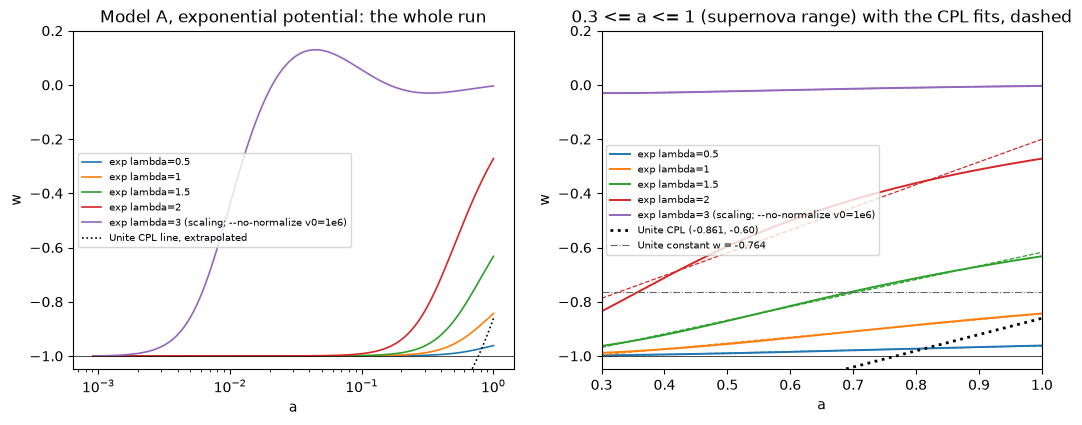

figure: results/nb01_w_of_a_other.png


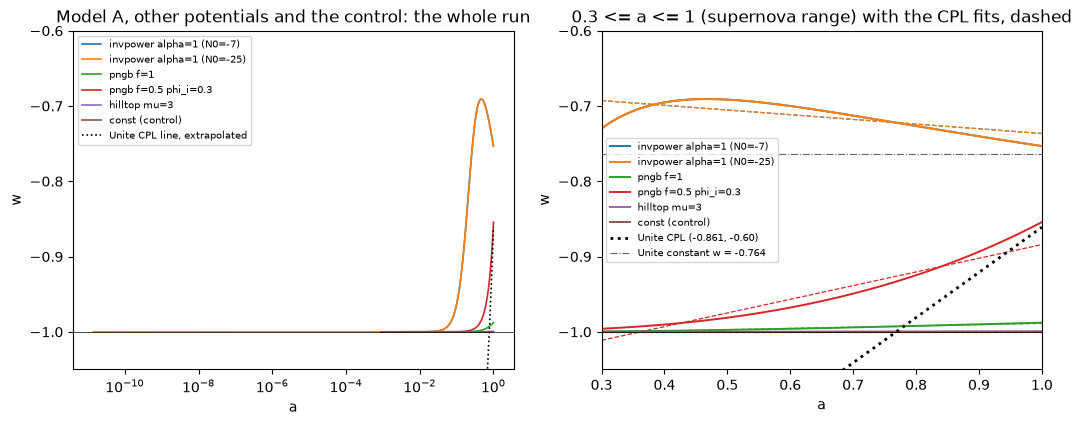

figure: results/nb01_w_of_a_cpl.png


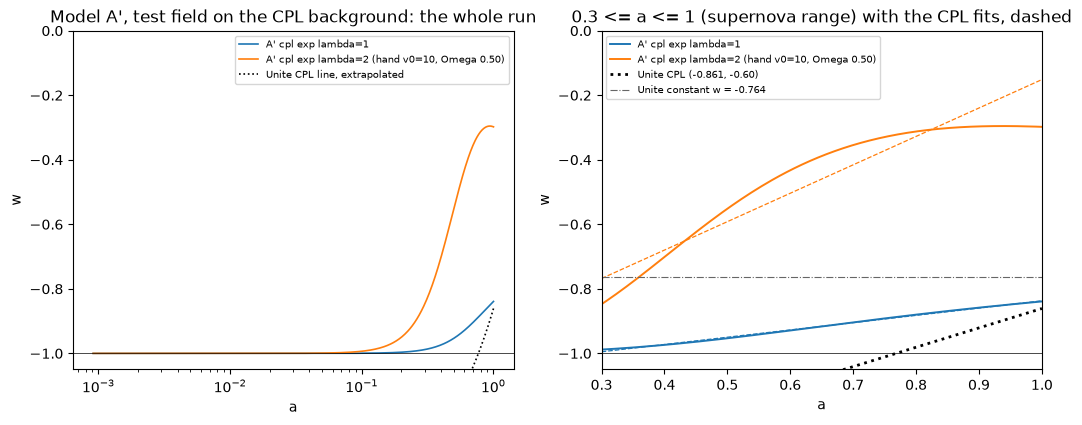

In [7]:
EXP_RUNS = ['nb01_exp_lambda0.5', 'nb01_exp_lambda1', 'nb01_exp_lambda1.5', 'nb01_exp_lambda2', 'nb01_exp_lambda3_scaling']
OTHER_RUNS = ['nb01_invpower_alpha1', 'nb01_invpower_alpha1_n0-25', 'nb01_pngb_f1', 'nb01_pngb_f0.5', 'nb01_hilltop_mu3', 'nb01_const']
CPL_RUNS = ['nb01_cpl_exp_lambda1', 'nb01_cpl_exp_lambda2_hand']
entries = lambda names: [(RUNS[n]['label'], RUNS[n]['table'], 'w_phi') for n in names]
plot_w_of_a(entries(EXP_RUNS), 'nb01_w_of_a_exp.png', 'Model A, exponential potential', ylim=(-1.05, 0.2))
plot_w_of_a(entries(OTHER_RUNS), 'nb01_w_of_a_other.png', 'Model A, other potentials and the control', ylim=(-1.05, -0.6))
plot_w_of_a(entries(CPL_RUNS), 'nb01_w_of_a_cpl.png', "Model A', test field on the CPL background", ylim=(-1.05, 0.0))

The Caldwell–Linder plane for the same runs.  The dot marks today; a trajectory that stays above
`w′ = 0` over `0.3 ≤ a ≤ 1` is thawing, one that stays below is freezing, one that crosses the
axis is mixed (the inverse-power runs, whose `w` overshoots and turns back; the `λ = 3` scaling
run, which oscillates about the background's `w`).

figure: results/nb01_caldwell_linder.png


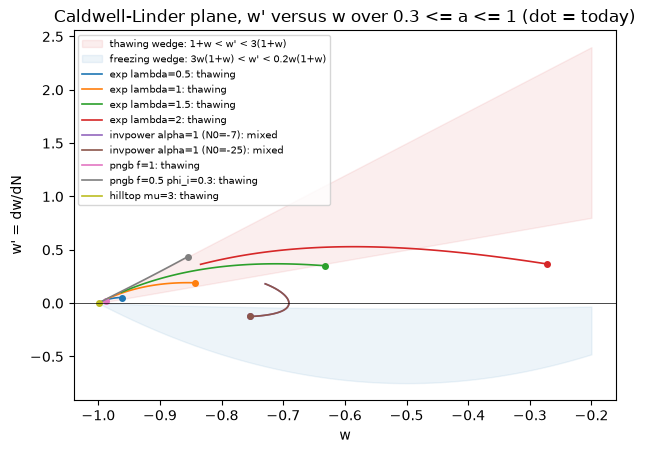

In [8]:
plot_caldwell_linder(entries(EXP_RUNS[:4] + OTHER_RUNS[:5]), 'nb01_caldwell_linder.png', "Caldwell-Linder plane, w' versus w over 0.3 <= a <= 1")

### 5.6 The CPL fit table

For every run: the unweighted least-squares fit of `w(a)` to `w0 + wa (1 − a)` over
`0.3 ≤ a ≤ 1` (numpy.polyfit on `1 − a`), the extrapolation `w0 + wa` of the fitted line to
`a = 0`, the *true* `w(a = 0.3)`, `w(1)` and `min w` over the whole run, the class, the field's
`Ω` today and the Euclidean distance of `(w0, wa)` from Unite's point, printed next to Unite's
`(−0.861, −0.60, w0 + wa = −1.461)` and the constant-w fit `−0.764`, and written to
`results/nb01_cpl_fits.csv` (with the two Unite rows appended for reference).

In [9]:
FIT_RUNS = EXP_RUNS + OTHER_RUNS + CPL_RUNS
fits01 = [fit_row(n, 'w_phi') for n in FIT_RUNS]
fit_table(fits01, RESULTS / 'nb01_cpl_fits.csv')

run                                            w0_fit   wa_fit    w0+wa   w(0.3)     w(1)    min w  class     Omega(1)   dist
-----------------------------------------------------------------------------------------------------------------------------
exp lambda=0.5                                -0.9627  -0.0532  -1.0159  -0.9976  -0.9616  -1.0000  thawing     0.6999  0.556
exp lambda=1                                  -0.8440  -0.2172  -1.0612  -0.9887  -0.8434  -1.0000  thawing     0.6999  0.383
exp lambda=1.5                                -0.6176  -0.5015  -1.1191  -0.9632  -0.6322  -1.0000  thawing     0.6999  0.263
exp lambda=2                                  -0.2004  -0.8384  -1.0388  -0.8355  -0.2720  -1.0000  thawing     0.6999  0.702
exp lambda=3 (scaling; --no-normalize v0=1e6)  -0.0020  -0.0427  -0.0448  -0.0299  -0.0039  -1.0000  mixed       0.3375  1.024
invpower alpha=1 (N0=-7)                      -0.7365   0.0625  -0.6741  -0.7298  -0.7532  -1.0000  mixed       0.699

### 5.7 Cross-check: every run re-integrated with scipy (DOP853, rtol = 1e−11)

`scipy_scalar` takes the run's own initial state and the potential *as normalised by the
solver* (parsed from its `# potential=` line), integrates the same three equations with a
completely different method (the explicit Dormand–Prince 8(5,3) pair at `rtol = 1e−11`,
`atol = 1e−14`) on the same 701 values of `N`, and reports `max |w_rust − w_scipy|` and
`max |t_rust − t_scipy|`.  The notebook fails if any difference in `w` exceeds `1e−6`; the
values are in fact at the level of the solver's own tolerance, a few parts in 10⁹ at worst.

In [10]:
xcheck01 = {}
for n in FIT_RUNS:
    dw, dt, _ = scipy_scalar(n, cpl=RUNS[n]['model'] == 'scalar-cpl')
    xcheck01[n] = dw
    print(f'{RUNS[n]["label"]:46s} max|w_rust - w_scipy| = {dw:.3e}   max|t_rust - t_scipy| = {dt:.3e}')
    assert dw < 1e-6, f'{n}: the scipy cross-check differs by {dw}'
print(f'\nlargest difference in w over all {len(FIT_RUNS)} runs: {max(xcheck01.values()):.3e}')

exp lambda=0.5                                 max|w_rust - w_scipy| = 1.824e-11   max|t_rust - t_scipy| = 3.271e-10
exp lambda=1                                   max|w_rust - w_scipy| = 9.509e-11   max|t_rust - t_scipy| = 2.791e-10
exp lambda=1.5                                 max|w_rust - w_scipy| = 1.101e-09   max|t_rust - t_scipy| = 3.725e-10
exp lambda=2                                   max|w_rust - w_scipy| = 4.095e-09   max|t_rust - t_scipy| = 3.733e-10
exp lambda=3 (scaling; --no-normalize v0=1e6)  max|w_rust - w_scipy| = 4.028e-09   max|t_rust - t_scipy| = 4.937e-10
invpower alpha=1 (N0=-7)                       max|w_rust - w_scipy| = 1.765e-09   max|t_rust - t_scipy| = 2.086e-10
invpower alpha=1 (N0=-25)                      max|w_rust - w_scipy| = 7.772e-10   max|t_rust - t_scipy| = 1.334e-10
pngb f=1                                       max|w_rust - w_scipy| = 1.161e-11   max|t_rust - t_scipy| = 1.099e-09
pngb f=0.5 phi_i=0.3                           max|w_rust - w_sc

### 5.8 Three integrators on the reference case: CVODE (Rust), DOP853 (scipy), NDSolve (Mathematica)

`reference/mathematica_scalar_exp.csv` was written by Part VI of the Mathematica notebook
(`reference/make_reference.wls`): the same equations, the same `Ω_m0, Ω_r0`, the same frozen
start, the same normalised `V0 = 2.6871520526047146` (the value the solver printed above for
`λ = 1`), integrated by `NDSolve` at 24-digit working precision and exported on the same 701
values of `N`.  The cell compares all three pairwise on `w`, and Rust against Mathematica on
`φ`, `φ̇`, `H` and `t`.

In [11]:
ref = np.genfromtxt(REFERENCE / 'mathematica_scalar_exp.csv', delimiter=',', names=True)
d = RUNS['nb01_exp_lambda1']['table']
assert ref.shape == d.shape and np.abs(ref['N'] - d['N']).max() < 1e-12, 'the reference grid must be the solver grid'
_, _, w_scipy = scipy_scalar('nb01_exp_lambda1')
threeway01 = {'rust-mathematica': float(np.abs(ref['w_phi'] - d['w_phi']).max()),
              'scipy-mathematica': float(np.abs(ref['w_phi'] - w_scipy).max()),
              'rust-scipy': float(np.abs(d['w_phi'] - w_scipy).max())}
for k, v in threeway01.items():
    print(f'max |w difference| {k:18s} = {v:.3e}')
for c in ['phi', 'phidot', 'H', 't']:
    print(f'max |{c} rust - mathematica| = {np.abs(ref[c] - d[c]).max():.3e}   (max relative {(np.abs(ref[c] - d[c]) / np.maximum(np.abs(ref[c]), 1e-300)).max():.3e})')
print(f'w(a=1): rust {d["w_phi"][-1]:.12f}  scipy {w_scipy[-1]:.12f}  mathematica {ref["w_phi"][-1]:.12f}')
assert threeway01['rust-mathematica'] < 1e-8 and threeway01['rust-scipy'] < 1e-8

max |w difference| rust-mathematica   = 1.149e-10
max |w difference| scipy-mathematica  = 1.313e-10
max |w difference| rust-scipy         = 9.509e-11
max |phi rust - mathematica| = 3.722e-10   (max relative 2.804e-04)
max |phidot rust - mathematica| = 6.153e-10   (max relative 3.683e-06)
max |H rust - mathematica| = 8.872e-11   (max relative 8.872e-11)
max |t rust - mathematica| = 5.428e-10   (max relative 1.578e-07)
w(a=1): rust -0.843363804027  scipy -0.843363803932  mathematica -0.843363803931


### 5.9 A finer scan in λ, to answer "which λ" precisely

The five values above bracket the answer; this scan runs `λ = 0.5, 0.6, …, 2.0` (16 quick runs,
CSV taken from the solver's stdout, nothing written), fits each, and plots the path of
`(w0, wa)` with Unite's point.  It also interpolates the `λ` at which the fitted `wa` equals
`−0.60` and reports the true `w(a = 0.3)` and `min w` there.  The scan table is written to
`results/nb01_lambda_scan.csv`.

$ fable_cosmo scalar-flrw --potential exp --param lambda=0.5
  # stats: model=scalar-flrw steps=384 rhs_evals=424 nonlin_iters=421 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=0.6
  # stats: model=scalar-flrw steps=366 rhs_evals=415 nonlin_iters=412 err_test_fails=6
$ fable_cosmo scalar-flrw --potential exp --param lambda=0.7
  # stats: model=scalar-flrw steps=365 rhs_evals=410 nonlin_iters=407 err_test_fails=4
$ fable_cosmo scalar-flrw --potential exp --param lambda=0.8
  # stats: model=scalar-flrw steps=368 rhs_evals=414 nonlin_iters=411 err_test_fails=4


$ fable_cosmo scalar-flrw --potential exp --param lambda=0.9


  # stats: model=scalar-flrw steps=372 rhs_evals=422 nonlin_iters=419 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.0
  # stats: model=scalar-flrw steps=385 rhs_evals=434 nonlin_iters=431 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.1
  # stats: model=scalar-flrw steps=388 rhs_evals=437 nonlin_iters=434 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.2


  # stats: model=scalar-flrw steps=391 rhs_evals=440 nonlin_iters=437 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.3
  # stats: model=scalar-flrw steps=411 rhs_evals=461 nonlin_iters=458 err_test_fails=6
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.4
  # stats: model=scalar-flrw steps=421 rhs_evals=466 nonlin_iters=463 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.5
  # stats: model=scalar-flrw steps=399 rhs_evals=452 nonlin_iters=449 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.6


 # stats: model=scalar-flrw steps=389 rhs_evals=440 nonlin_iters=437 err_test_fails=4
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.7
  # stats: model=scalar-flrw steps=435 rhs_evals=483 nonlin_iters=480 err_test_fails=5
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.8
  # stats: model=scalar-flrw steps=409 rhs_evals=465 nonlin_iters=462 err_test_fails=7
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.9
  # stats: model=scalar-flrw steps=436 rhs_evals=492 nonlin_iters=489 err_test_fails=7


$ fable_cosmo scalar-flrw --potential exp --param lambda=2.0
  # stats: model=scalar-flrw steps=433 rhs_evals=498 nonlin_iters=495 err_test_fails=8

lambda       w0       wa    dist     w(1)   w(0.3)    min w
  0.50  -0.9627  -0.0532  0.5562  -0.9616  -0.9976  -1.0000
  0.60  -0.9460  -0.0768  0.5300  -0.9446  -0.9965  -1.0000
  0.70  -0.9259  -0.1050  0.4993  -0.9243  -0.9951  -1.0000
  0.80  -0.9023  -0.1377  0.4642  -0.9008  -0.9934  -1.0000
  0.90  -0.8751  -0.1750  0.4252  -0.8738  -0.9913  -1.0000
  1.00  -0.8440  -0.2172  0.3832  -0.8434  -0.9887  -1.0000
  1.10  -0.8087  -0.2642  0.3399  -0.8093  -0.9856  -1.0000
  1.20  -0.7689  -0.3161  0.2984  -0.7714  -0.9817  -1.0000
  1.30  -0.7242  -0.3731  0.2650  -0.7294  -0.9769  -1.0000
  1.40  -0.6740  -0.4349  0.2495  -0.6832  -0.9709  -1.0000
  1.50  -0.6176  -0.5015  0.2626  -0.6322  -0.9632  -1.0000
  1.60  -0.5543  -0.5722  0.3079  -0.5759  -0.9530  -1.0000
  1.70  -0.4829  -0.6459  0.3808  -0.5135  -0.9390  -1.0000
  1.80  -0.

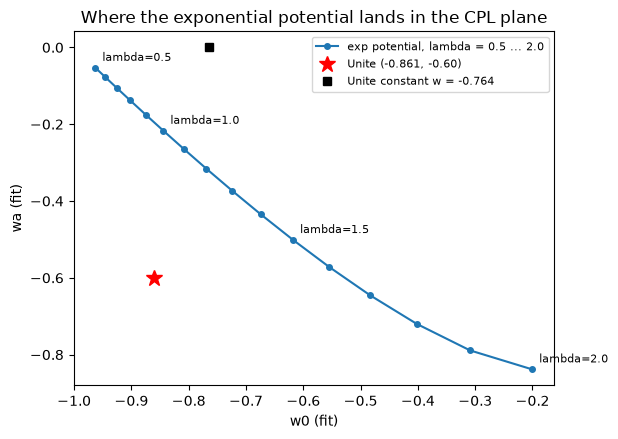

In [12]:
scan = []
for lam in np.round(np.arange(0.5, 2.001, 0.1), 2):
    d = run_solver(f'scan_lambda{lam}', 'scalar-flrw', '--potential', 'exp', '--param', f'lambda={lam}', keep=False, quiet=True)
    w0, wa = cpl_fit(d['a'], d['w_phi'])
    scan.append((lam, w0, wa, np.hypot(w0 - UNITE_W0, wa - UNITE_WA), d['w_phi'][-1], w_at(d['a'], d['w_phi'], 0.3), d['w_phi'].min()))
scan = np.array(scan)
print(f"\n{'lambda':>6s} {'w0':>8s} {'wa':>8s} {'dist':>7s} {'w(1)':>8s} {'w(0.3)':>8s} {'min w':>8s}")
for row in scan:
    print(f'{row[0]:6.2f} {row[1]:8.4f} {row[2]:8.4f} {row[3]:7.4f} {row[4]:8.4f} {row[5]:8.4f} {row[6]:8.4f}')
with open(RESULTS / 'nb01_lambda_scan.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['lambda', 'w0_fit', 'wa_fit', 'dist_to_unite', 'w_a1', 'w_a03', 'w_min']); wr.writerows(scan.tolist())
i = scan[:, 3].argmin()
lam_wa06 = float(np.interp(-0.60, scan[::-1, 2], scan[::-1, 0]))
print(f'\nclosest to Unite in the (w0, wa) plane: lambda = {scan[i, 0]:.1f} with (w0, wa) = ({scan[i, 1]:+.4f}, {scan[i, 2]:+.4f}), distance {scan[i, 3]:.4f}')
print(f'wa = -0.60 is reached at lambda = {lam_wa06:.3f}, where w(a=0.3) = {np.interp(lam_wa06, scan[:, 0], scan[:, 5]):+.4f} and w0 = {np.interp(lam_wa06, scan[:, 0], scan[:, 1]):+.4f}; min w over every scan run = {scan[:, 6].min():+.6f}')
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.plot(scan[:, 1], scan[:, 2], 'o-', ms=4, label='exp potential, lambda = 0.5 ... 2.0')
for row in scan[::5]:
    ax.annotate(f'lambda={row[0]:.1f}', (row[1], row[2]), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.plot(UNITE_W0, UNITE_WA, 'r*', ms=12, label='Unite (-0.861, -0.60)')
ax.plot(UNITE_WCONST, 0.0, 'ks', ms=6, label='Unite constant w = -0.764')
ax.set_xlabel('w0 (fit)'); ax.set_ylabel('wa (fit)'); ax.legend(fontsize=8); ax.set_title('Where the exponential potential lands in the CPL plane')
fig.savefig(RESULTS / 'nb01_lambda_scan.png', dpi=130, bbox_inches='tight'); print('figure: results/nb01_lambda_scan.png'); plt.show()

## 6. This notebook's results

Everything this notebook writes lives under `results/` and is committed as the evidence:

- `results/nb01_exp_lambda0.5.csv`, `results/nb01_exp_lambda1.csv`, `results/nb01_exp_lambda1.5.csv`,
  `results/nb01_exp_lambda2.csv`, `results/nb01_exp_lambda3_scaling.csv` — Model A, exponential potential;
- `results/nb01_invpower_alpha1.csv`, `results/nb01_invpower_alpha1_n0-25.csv` — inverse power, two starts;
- `results/nb01_pngb_f1.csv`, `results/nb01_pngb_f0.5.csv`, `results/nb01_hilltop_mu3.csv`, `results/nb01_const.csv`;
- `results/nb01_cpl_exp_lambda1.csv`, `results/nb01_cpl_exp_lambda2_hand.csv` — Model A′;
- `results/nb01_cpl_fits.csv` — the CPL fit table of 5.6; `results/nb01_lambda_scan.csv` — the scan of 5.9;
- `results/nb01_w_of_a_exp.png`, `results/nb01_w_of_a_other.png`, `results/nb01_w_of_a_cpl.png`,
  `results/nb01_caldwell_linder.png`, `results/nb01_lambda_scan.png` — the figures.

The solver's CSVs are plain text: the cell below reads the fit table back with Python's `csv`
module alone (no numpy, no solver), as anyone can, and prints it.

In [13]:
import csv
with open(RESULTS / 'nb01_cpl_fits.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'{len(rows)} rows, columns: {", ".join(rows[0].keys())}')
for r in rows:
    print(f"{r['run']:46s} w0 = {float(r['w0_fit']):+.4f}  wa = {float(r['wa_fit']):+.4f}  w0+wa = {float(r['w0_plus_wa']):+.4f}  class = {r['class']}")

15 rows, columns: run, model, w0_fit, wa_fit, w0_plus_wa, w_a03, w_a1, w_min, class, omega_today, dist_to_unite


exp lambda=0.5                                 w0 = -0.9627  wa = -0.0532  w0+wa = -1.0159  class = thawing
exp lambda=1                                   w0 = -0.8440  wa = -0.2172  w0+wa = -1.0612  class = thawing
exp lambda=1.5                                 w0 = -0.6176  wa = -0.5015  w0+wa = -1.1191  class = thawing
exp lambda=2                                   w0 = -0.2004  wa = -0.8384  w0+wa = -1.0388  class = thawing
exp lambda=3 (scaling; --no-normalize v0=1e6)  w0 = -0.0020  wa = -0.0427  w0+wa = -0.0448  class = mixed
invpower alpha=1 (N0=-7)                       w0 = -0.7365  wa = +0.0625  w0+wa = -0.6741  class = mixed
invpower alpha=1 (N0=-25)                      w0 = -0.7365  wa = +0.0625  w0+wa = -0.6741  class = mixed
pngb f=1                                       w0 = -0.9888  wa = -0.0165  w0+wa = -1.0053  class = thawing
pngb f=0.5 phi_i=0.3                           w0 = -0.8841  wa = -0.1817  w0+wa = -1.0657  class = thawing
hilltop mu=3                     

## 7. The questions, answered from the numbers

**Which λ of the exponential potential comes closest to Unite's `(w0, wa) = (−0.861, −0.60)`?**
Of the five values run, `λ = 1.5`: its fit is `(w0, wa) = (−0.618, −0.502)`, at a distance of
0.263 from Unite's point in the `(w0, wa)` plane; `λ = 1` is next (`(−0.844, −0.217)`, distance
0.383).  No single `λ` matches both numbers: `λ = 1` reproduces `w0` (−0.844 against −0.861) but
only a third of the slope, `λ = 1.5` reproduces most of the slope but has `w0 = −0.62`.  The
finer scan of 5.9 puts the minimum of the distance at `λ = 1.4` (`(−0.674, −0.435)`, distance
0.249), and the fitted `wa` reaches exactly −0.60 at `λ ≈ 1.64`, where `w0 ≈ −0.53`.  A thawing
exponential field with the frozen start therefore gives Unite's *sign pattern* (`w0 > −1`,
`wa < 0`) and can give either Unite number, but not the pair.

**Is `|wa| = 0.6` reachable while `w` never drops below −1?**  Yes.  Every Model A run has
`min w = −1.000000` (the frozen start) and never less — the null energy condition
`ρ + P = 2 KE ≥ 0` forbids it — yet `λ = 1.5` fits `wa = −0.50`, `λ ≈ 1.64` fits `wa = −0.60`
and `λ = 2` fits `wa = −0.84`.  The fitted line extrapolates to `w0 + wa = −1.12` (`λ = 1.5`) and
`−1.04` (`λ = 2`) at `a = 0`, below the phantom divide, while the true `w(a = 0.3)` there is
`−0.963` (`λ = 1.5`), `≈ −0.95` (`λ ≈ 1.64`) and `−0.836` (`λ = 2`): the "phantom past" of the CPL
fit is the straight line leaving the curved `w(a)`, which is concave over the supernova range
(it rises slowly from −1 and then faster), not a measurement of `w < −1`.  A thawing canonical
field with `w0 + wa < −1` in the CPL extrapolation is what these numbers show.

**The other potentials.**  The inverse power (α = 1) does not join its tracker from a frozen
start even from `N0 = −25`; it thaws to `w(1) = −0.753` with `wa ≈ +0.06` (mixed), nowhere near
Unite's slope.  The PNGB potentials thaw mildly (`f = 1`: `(−0.989, −0.017)`; `f = 0.5` from
`φ_i = 0.3`: `(−0.884, −0.182)`), the hilltop with `μ = 3` is still almost frozen
(`(−0.999, −0.001)`), the control is `w = −1` to machine precision.  `λ = 3` is not a
dark-energy model at all: on its scaling attractor it carries `Ω_φ = 0.34 ≈ 3/λ²` with
`w ≈ 0` today and no acceleration.  On the Unite CPL background (Model A′) `λ = 1` gives
`(−0.837, −0.226)`, essentially the self-consistent result, and `λ = 2` cannot carry
`Ω_DE = 0.70` (it saturates at 0.50) — a test field with `λ² > 3` scales with the background.

The cell below re-derives every number quoted in this section from the tables above and
fails if the text has gone stale.

In [14]:
F = {r['run']: r for r in fits01}
closest = min((r for r in fits01 if r['run'].startswith('exp lambda=') and 'scaling' not in r['run']), key=lambda r: r['dist_to_unite'])
print('closest of the five exponential runs:', closest['run'], f"(w0, wa) = ({closest['w0_fit']:+.4f}, {closest['wa_fit']:+.4f}), distance {closest['dist_to_unite']:.4f}")
assert closest['run'] == 'exp lambda=1.5' and abs(closest['w0_fit'] + 0.618) < 2e-3 and abs(closest['wa_fit'] + 0.502) < 2e-3 and abs(closest['dist_to_unite'] - 0.263) < 2e-3
assert abs(F['exp lambda=1']['w0_fit'] + 0.844) < 2e-3 and abs(F['exp lambda=1']['wa_fit'] + 0.217) < 2e-3 and abs(F['exp lambda=1']['dist_to_unite'] - 0.383) < 2e-3
assert scan[scan[:, 3].argmin(), 0] == 1.4 and abs(lam_wa06 - 1.64) < 0.01
assert all(abs(r['w_min'] + 1.0) < 1e-6 for r in fits01 if r['model'] == 'scalar-flrw'), 'no Model A run may go below w = -1'
assert abs(F['exp lambda=1.5']['w0_plus_wa'] + 1.12) < 5e-3 and abs(F['exp lambda=2']['w0_plus_wa'] + 1.04) < 5e-3
assert abs(F['exp lambda=1.5']['w_a03'] + 0.963) < 2e-3 and abs(F['exp lambda=2']['w_a03'] + 0.836) < 2e-3 and abs(F['exp lambda=2']['wa_fit'] + 0.84) < 5e-3
assert abs(F['invpower alpha=1 (N0=-7)']['w_a1'] + 0.753) < 2e-3 and F['invpower alpha=1 (N0=-7)']['class'] == 'mixed'
assert abs(F['exp lambda=3 (scaling; --no-normalize v0=1e6)']['omega_today'] - 0.34) < 5e-3
assert abs(F["A' cpl exp lambda=1"]['w0_fit'] + 0.837) < 2e-3 and abs(F["A' cpl exp lambda=2 (hand v0=10, Omega 0.50)"]['omega_today'] - 0.50) < 5e-3
assert F['const (control)']['class'] == 'constant'
print('every number quoted in section 7 agrees with the tables')

closest of the five exponential runs: exp lambda=1.5 (w0, wa) = (-0.6176, -0.5015), distance 0.2626
every number quoted in section 7 agrees with the tables


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [15]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '01_fableScalar_quintessence'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '01_fableScalar_quintessence'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 01_fableScalar_quintessence


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [16]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '01_fableScalar_quintessence.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
